1. Choix et importation de la base de données,  
    OASIS 1 seulement utiliser 3 catégorie (Mild Dementia, Non Demented, Very Mild Dementia) J'ai 10 patient par catégorie
    Par patient, j'ai pris 25 slice (80 à 104 sur fichier.hdr)
2. Exploration et prétraitement des données, 
    J'ai repris le travail qu'on avait regarde avec Madhi.

3. Extraction et représentation des caractéristiques, 
4. Sélection des caractéristiques ou réduction de dimension, 
5. Choix et étude de l’algorithme d’apprentissage supervisé, 
    SVM
6. Étude des hyperparamètres et des variantes de l’algorithme, 
7. Évaluation des performances selon différentes stratégies de validation, 
8. Analyse et interprétation des résultats, 
9. Bilan critique de l’algorithme étudié.

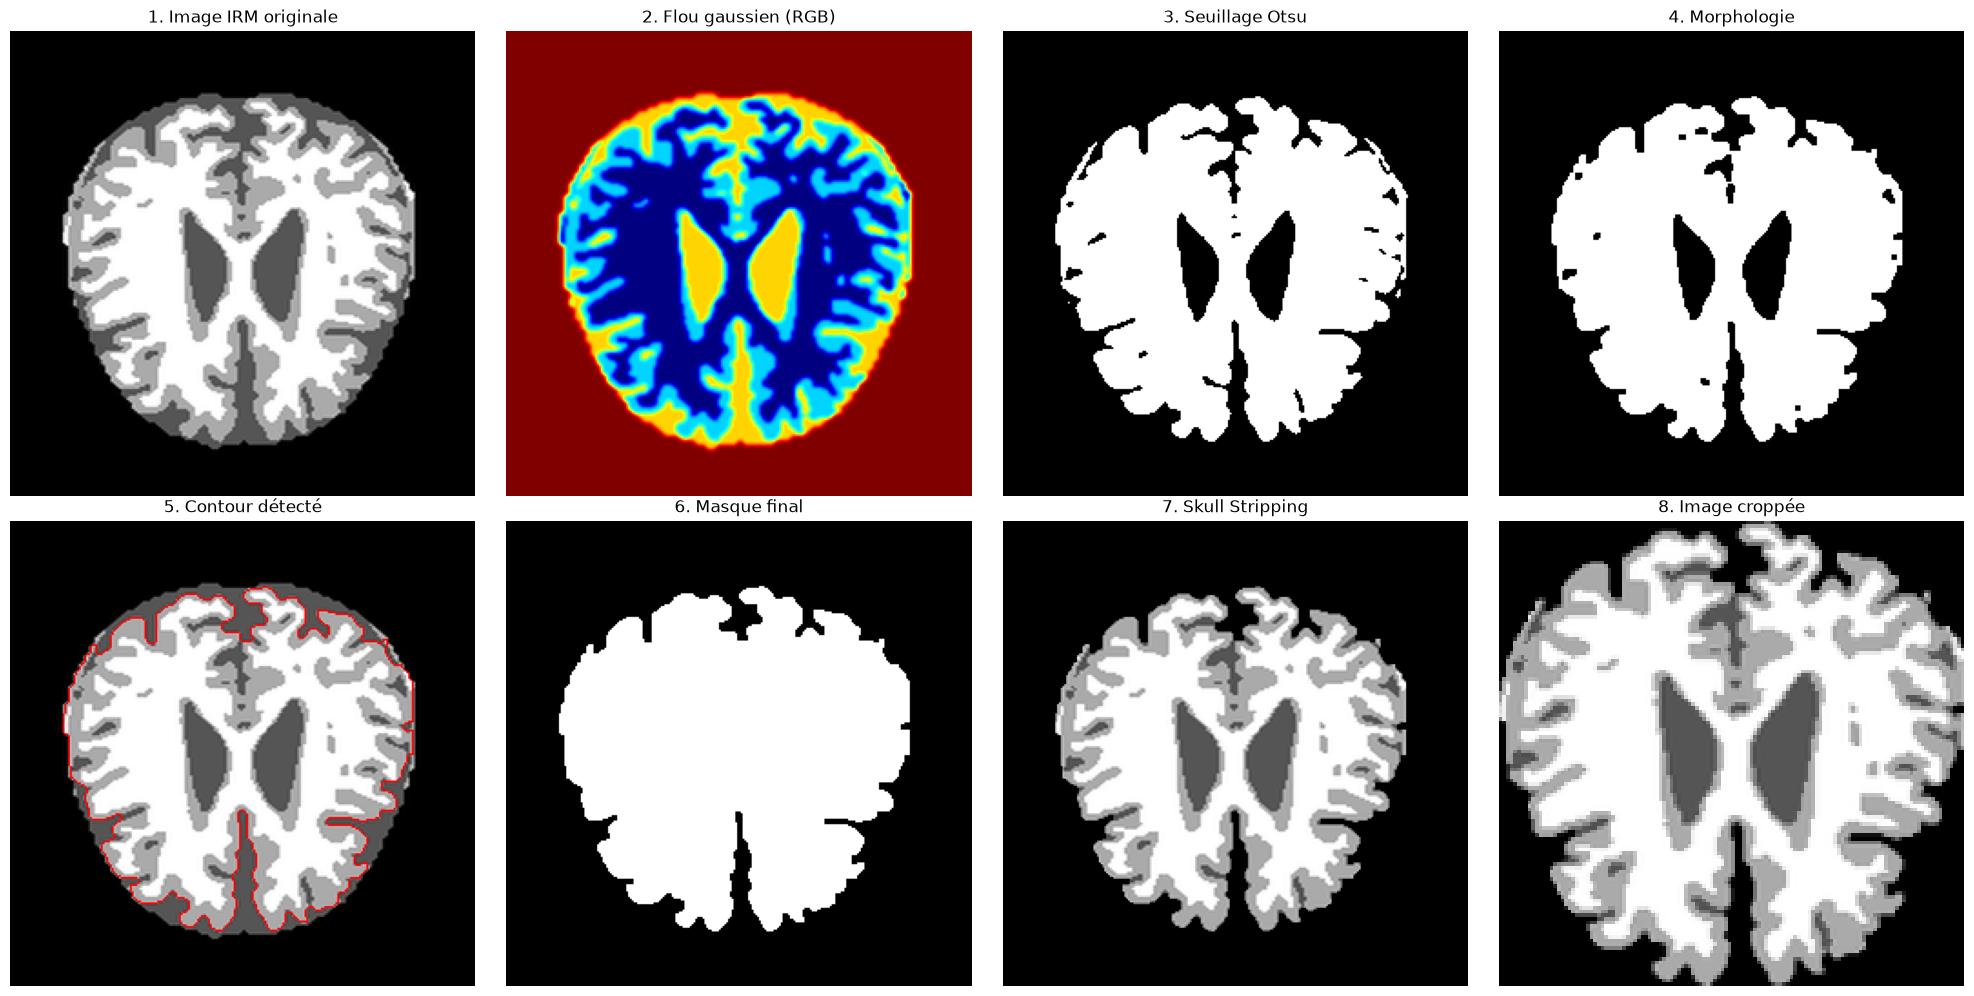

In [82]:
#2. Exploration et prétraitement des données
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Chargement de l'image IRM ===
image_path = Path(
    "data/raw/Mild Demented/OAS1_0028_MR1_final/0028_nii_slice_025.png"
)
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Image non trouvée.")

# === Étape 1 : Flou Gaussien ===
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# === Étape 2 : Seuillage Otsu ===
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# === Étape 3 : Morphologie (nettoyage doux pour garder les détails) ===
kernel = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)

# === Étape 4 : Détection des contours internes (pas juste le plus grand) ===
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask = np.zeros_like(img)

# Conserver les contours situés vers le centre de l'image
for c in contours:
    M = cv2.moments(c)
    if M["m00"] == 0:
        continue
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    if (img.shape[1]*0.15 < cx < img.shape[1]*0.85) and (img.shape[0]*0.15 < cy < img.shape[0]*0.85):
        cv2.drawContours(mask, [c], -1, 255, thickness=cv2.FILLED)

# === Étape 5 : Application du masque ===
brain_only = cv2.bitwise_and(img, mask)

# === Étape 6 : Cropping autour du cerveau ===
x, y, w, h = cv2.boundingRect(mask)
cropped_brain = brain_only[y:y+h, x:x+w]
cropped_resized = cv2.resize(cropped_brain, (128, 128))

# === VISUALISATION ===
blurred_rgb = cv2.applyColorMap(blurred, cv2.COLORMAP_JET)
contour_overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for c in contours:
    cv2.drawContours(contour_overlay, [c], -1, (255, 0, 0), 1)
mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
steps = [
    (img, "1. Image IRM originale", 'gray'),
    (blurred_rgb, "2. Flou gaussien (RGB)", None),
    (thresh, "3. Seuillage Otsu", 'gray'),
    (cleaned, "4. Morphologie", 'gray'),
    (contour_overlay, "5. Contour détecté", None),
    (mask_rgb, "6. Masque final", None),
    (brain_only, "7. Skull Stripping", 'gray'),
    (cropped_resized, "8. Image croppée", 'gray'),
]

for ax, (image, title, cmap) in zip(axs.ravel(), steps):
    ax.imshow(image, cmap=cmap) if cmap else ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [83]:
#3. Extraction et représentation des caractéristiques, Les images se trouvent dans le dossier data/raw,
# LBP (Local Binary Patterns) est une méthode efficace pour extraire des caractéristiques de texture à partir d'images.

from skimage.feature import local_binary_pattern

input_dir = Path("data/raw")
output_dir = Path("data/treated")
image_extensions = {".png"}
all_histograms = []

def apply_lbp(image_path: Path, output_path: Path):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Image impossible à lire : {image_path}")
        return None

    # FIXME: === Ajuster les paramètres du LBP ===
    lbp = local_binary_pattern(
        image,
        P=8, # nombre de point
        R=3, # rayon
        method="default"
    )
    """
    method
    default: This is the original local binary pattern. It is grayscale invariant but not rotation invariant.
    ror: This is an extension of the default pattern and is both grayscale and rotation invariant.
    uniform: This method produces a uniform pattern that is both grayscale and rotation invariant. It offers finer quantization of the angular space, making it suitable for texture classification tasks.
    nri_uniform: This is a variant of the uniform pattern that is grayscale invariant but not rotation invariant.
    var: This method computes the variance of local image texture, which is related to contrast. It is rotation invariant but not grayscale invariant.
    """

    # === Conversion pour sauvegarder l'image LBP ===
    lbp_image = np.clip(lbp, 0, 255).astype(np.uint8)

    # === Sauvegarde de l'image ===
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), lbp_image)

    # === Calcul de l'histogramme ===
    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(257),
        range=(0, 256)
    )

    return histogram


for image_path in input_dir.rglob("*"):

    if image_path.is_file() and image_path.suffix.lower() in image_extensions:
        relative_path = image_path.relative_to(input_dir)
        output_path = output_dir / relative_path
        histogram = apply_lbp(image_path, output_path)

        # === Stockage de l'histogramme et le label ===
        if histogram is not None:
            all_histograms.append({
                "image_path": str(relative_path),
                "histogram": histogram,
                "label": relative_path.parts[0]
            })

print(f"Nombre total d'histogrammes: {len(all_histograms)}")





Nombre total d'histogrammes: 750


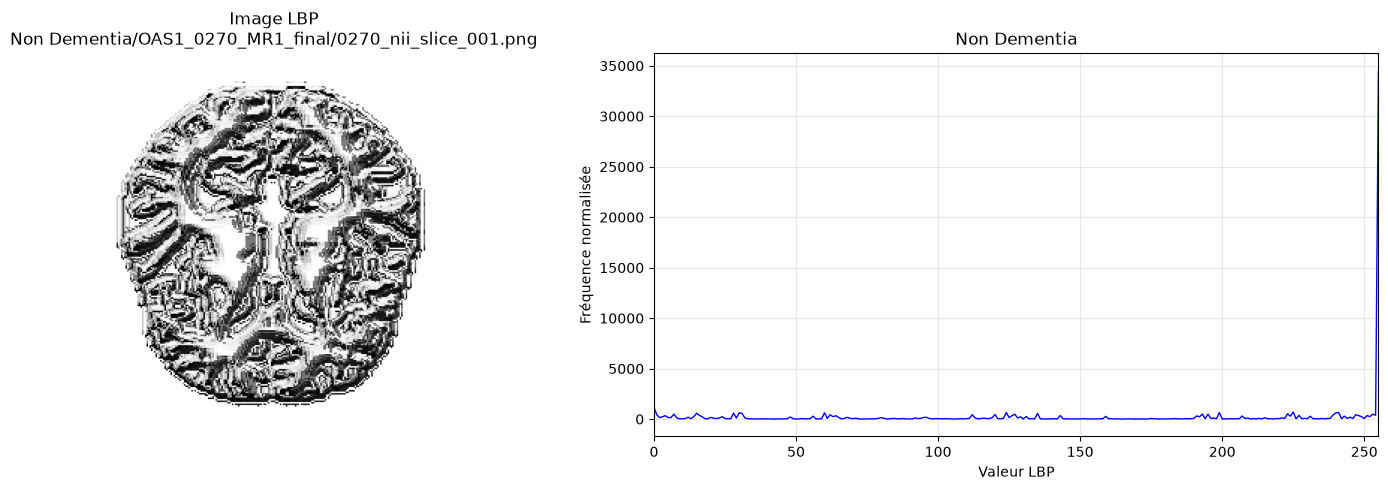

In [84]:
#3. Extraction et représentation des caractéristiques, Suite
# Exploration des histogrammes LBP et visualisation de la première image traitée

# === Récupération du premier histogramme et image traitée ===
X_ITEM = 150
x_histogramme = all_histograms[X_ITEM]["histogram"]
x_image = all_histograms[X_ITEM]["image_path"]
x_label = all_histograms[X_ITEM]["label"]
x_image_path = output_dir / x_image


image_lbp = cv2.imread(
    str(x_image_path),
    cv2.IMREAD_GRAYSCALE
)
# === Affichage de l'image LBP et de l'histogramme ===
if image_lbp is None:
    print(f"Image impossible à lire : {x_image_path}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_lbp, cmap="gray")
    axes[0].set_title(f"Image LBP\n{x_image}")
    axes[0].axis("off")

    axes[1].plot(
        x_histogramme,
        color="blue",
        linewidth=1
    )

    axes[1].set_title(x_label)
    axes[1].set_xlabel("Valeur LBP")
    axes[1].set_ylabel("Fréquence normalisée")
    axes[1].set_xlim(0, 255)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()





In [85]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Pipeline SVM  LAISSEZ PAR DEFAULT
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("PCA", PCA(
        n_components=0.95,
        svd_solver="auto",
        power_iteration_normalizer="auto",
    )),
    ("svm", SVC(
        kernel="linear",
        C=10,
        gamma="scale",
        coef0=0.0,
    ))
])


In [86]:
from sklearn.model_selection import train_test_split

x = np.asarray(
    [item["histogram"] for item in all_histograms],
    dtype=np.float32
)
y = np.asarray([item["label"] for item in all_histograms])

if x.ndim != 2:
    raise ValueError("Les histogrammes doivent tous avoir la même longueur.")

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Images d'entraînement : {len(x_train)}")
print(f"Images de test : {len(x_test)}")

Images d'entraînement : 600
Images de test : 150


In [87]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
param_grid = [
    {
        "PCA__n_components": [0.90, 0.95, 0.99],
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 0.5, 0.75, 0.9, 1, 10, 100],
    },
    {
        "PCA__n_components": [0.90, 0.95, 0.99],
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 0.5, 0.75, 0.9, 1, 10, 100],
        "svm__gamma": ["scale", "auto"],
    },
    {
        "PCA__n_components": [0.90, 0.95, 0.99],
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 0.5, 0.75, 0.9, 1, 10, 100],
        "svm__gamma": ["scale", "auto"],
        "svm__coef0": [0, 0.1, 1],
    },
]

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid_search.fit(x_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print(f"Meilleure accuracy CV : {grid_search.best_score_:.3f}")

best_svm_pipeline = grid_search.best_estimator_


Meilleurs paramètres : {'PCA__n_components': 0.95, 'svm__C': 1, 'svm__coef0': 0.1, 'svm__gamma': 'auto', 'svm__kernel': 'poly'}
Meilleure accuracy CV : 0.858


In [88]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_svm_pipeline.predict(x_test)

print(f"Accuracy test : {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))



Accuracy test : 0.873
                    precision    recall  f1-score   support

     Mild Demented       0.89      0.89      0.89        55
      Non Dementia       0.87      0.88      0.88        52
Very Mild Demented       0.86      0.84      0.85        43

          accuracy                           0.87       150
         macro avg       0.87      0.87      0.87       150
      weighted avg       0.87      0.87      0.87       150



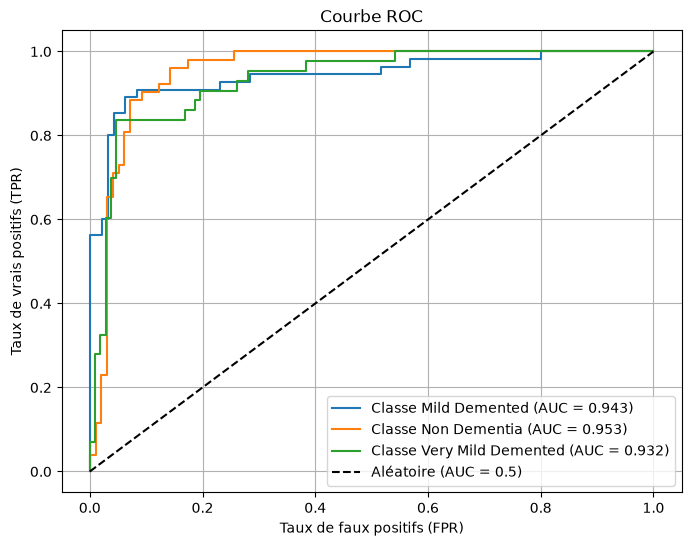

In [89]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = best_svm_pipeline.classes_
scores = best_svm_pipeline.decision_function(x_test)

plt.figure(figsize=(8, 6))

y_test_bin = label_binarize(y_test, classes=classes)
for i, classe in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Classe {classe} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Aléatoire (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
